# Solutions · 16 · Electrochemical thermodynamics

Worked solutions to the exercises of [notebook 16](../notebooks/16_electrochemical_thermodynamics.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import electrochem, reaction
from engthermo.constants import F, R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

A solid-oxide fuel cell at 800 degC runs on hydrogen and produces steam. Compute its reversible voltage and maximum efficiency, and compare with a 25 degC cell. Which loses more of the heating value as reversible heat?

In [2]:
steam_rxn = {"H2": -1, "O2": -0.5, "H2O": 1}
liquid_rxn = {"H2": -1, "O2": -0.5, "H2O(l)": 1}
sofc, pem = electrochem.fuel_cell_limits(steam_rxn, 2, 1073.15), electrochem.fuel_cell_limits(liquid_rxn, 2, 298.15)
for name, lim in (("SOFC at 800 degC (steam product)", sofc), ("PEM cell at 25 degC (liquid water)", pem)):
    print(f"{name:<36}: E_rev = {lim['E_rev']:.3f} V, max efficiency {lim['efficiency_max']:.1%}, reversible heat {(lim['dH'] - lim['dG'])/1e3:.1f} kJ/mol")

SOFC at 800 degC (steam product)    : E_rev = 0.977 V, max efficiency 75.9%, reversible heat -59.8 kJ/mol
PEM cell at 25 degC (liquid water)  : E_rev = 1.229 V, max efficiency 83.0%, reversible heat -48.7 kJ/mol


The high-temperature cell has a lower reversible voltage and a lower ceiling on efficiency: more of the
reaction enthalpy must leave as heat because the entropy change is larger at 800 degC with steam as the
product. In exchange it needs no platinum, tolerates carbon monoxide, and its waste heat is hot enough to
run a turbine - which is why SOFC systems reach the highest *system* efficiencies despite the lower cell limit.

## Exercise 2

Round trip: an electrolyser at 1.85 V feeds hydrogen to a fuel cell at 0.72 V. What fraction of the electricity returns? How does this compare with a pumped-hydro or battery storage round trip of 75-90 %?

In [3]:
lim = electrochem.fuel_cell_limits({"H2": -1, "O2": -0.5, "H2O(l)": 1}, 2)
eta_el = electrochem.electrolyser_efficiency(1.85, lim["E_thermoneutral"])
eta_fc = electrochem.efficiency_at_voltage(0.72, lim["E_thermoneutral"])
print(f"electrolyser at 1.85 V: {eta_el:.1%}; fuel cell at 0.72 V: {eta_fc:.1%}; round trip {eta_el * eta_fc:.1%} (voltage ratio 0.72/1.85 = {0.72/1.85:.1%})")

electrolyser at 1.85 V: 80.1%; fuel cell at 0.72 V: 48.6%; round trip 38.9% (voltage ratio 0.72/1.85 = 38.9%)


Less than 40 % of the electricity returns - the ratio of the two cell voltages, plus compression, storage and
auxiliary losses not counted here. Batteries and pumped hydro return 75-90 %. Hydrogen storage makes sense
where its other properties matter: seasonal storage, energy density for transport, or a chemical feedstock.

## Exercise 3

**Implement it yourself:** write the Nernst equation for the hydrogen cell as a function of p_H2, p_O2 and T, and plot E against temperature from 25 to 200 degC at 1 bar (use the steam reaction above 100 degC).

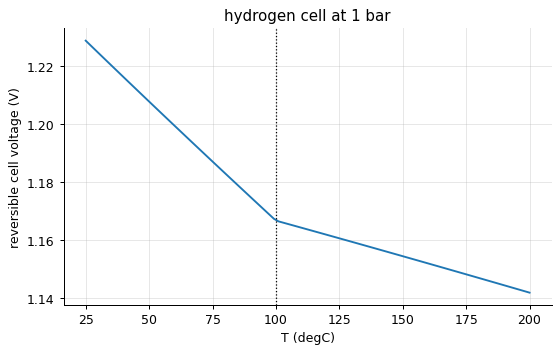

E at 25 degC 1.229 V, at 90 degC 1.175 V, at 150 degC 1.155 V (steam product)


In [4]:
def E_cell(T, p_H2=1.0, p_O2=1.0):
    rxn = {"H2": -1, "O2": -0.5, "H2O(l)": 1} if T < 373.15 else {"H2": -1, "O2": -0.5, "H2O": 1}
    E0 = electrochem.standard_potential(rxn, 2, T)
    return electrochem.nernst(E0, 2, 1 / (p_H2 * p_O2**0.5), T)
Ts = np.linspace(298.15, 473.15, 100)
plt.plot(Ts - 273.15, [E_cell(T) for T in Ts]); plt.axvline(100, color="k", ls=":", lw=1)
plt.xlabel("T (degC)"); plt.ylabel("reversible cell voltage (V)"); plt.title("hydrogen cell at 1 bar"); plt.show()
print(f"E at 25 degC {E_cell(298.15):.3f} V, at 90 degC {E_cell(363.15):.3f} V, at 150 degC {E_cell(423.15):.3f} V (steam product)")

The reversible voltage falls by about 0.85 mV per kelvin below 100 degC. At the boiling point the two branches
meet - liquid water and steam have the same Gibbs energy there at 1 bar, so the curve is continuous - and above
it the slope is gentler, because the entropy change of the reaction is smaller in magnitude when the product
is a gas.